In [1]:
import numpy as np

from bootstrap_diagnostics import DoubleBootstrap

In [2]:
rng = np.random.default_rng(123)

mean = 1.0
sample_size = 20
n_covers = 0
n_iterations = 500
seed = 42
confidence_level = 0.95

# for i in range(n_iterations):
sample = rng.exponential(scale=mean, size=sample_size)


def mean(x):
    return np.mean(x)


db = DoubleBootstrap(sample, mean)
ci = db.confidence_interval(confidence_level, seed=seed, side="two", n_jobs=-1)

# if ci.lower <= mean <= ci.upper:
# n_covers += 1

# print(f"Final coverage: {n_covers / n_iterations}")
print(ci)

lower = 0.48925326639695677
upper = 1.6712732012214104
confidence level = 0.95, side = two


In [3]:
ci = db.confidence_interval(confidence_level, seed=seed, side="two", n_jobs=4)
print(ci)

lower = 0.48925326639695677
upper = 1.6712732012214104
confidence level = 0.95, side = two


In [4]:
rng = np.random.default_rng(123)

true_corr = 0.5
mu = [1, 1]
cov_matrix = [
    [1.0, true_corr],
    [true_corr, 1.0],
]


def pearsonr(x):
    return np.corrcoef(x, rowvar=False)[0, 1]


n_covers = 0
n_iterations = 500
for i in range(n_iterations):
    data = rng.multivariate_normal(mean=mu, cov=cov_matrix, size=20)

    db = DoubleBootstrap(data, pearsonr)

    ci = db.confidence_interval(confidence_level, seed=seed, n_jobs=-1)

    if ci.lower <= true_corr <= ci.upper:
        n_covers += 1
    print(f"{i}, {ci} -> Coverage: {n_covers / (i + 1)}")

print(f"Final coverage: {n_covers / n_iterations}")

0, lower = -0.04712618550232408
upper = 0.836928122472993
confidence level = 0.95, side = two -> Coverage: 1.0
1, lower = 0.12690570406570267
upper = 0.8994176391083758
confidence level = 0.95, side = two -> Coverage: 1.0
2, lower = -0.3956273544627444
upper = 0.5034972355808129
confidence level = 0.95, side = two -> Coverage: 1.0
3, lower = 0.012406476272424215
upper = 0.9150555285148788
confidence level = 0.95, side = two -> Coverage: 1.0
4, lower = -0.1517516174807434
upper = 0.7688050085029552
confidence level = 0.95, side = two -> Coverage: 1.0
5, lower = -0.20909411634184855
upper = 0.7984516858423725
confidence level = 0.95, side = two -> Coverage: 1.0
6, lower = -0.23033037339345613
upper = 0.7062169708926763
confidence level = 0.95, side = two -> Coverage: 1.0
7, lower = -0.3438268993339747
upper = 0.8123063846992024
confidence level = 0.95, side = two -> Coverage: 1.0
8, lower = 0.04599001714761191
upper = 0.6983103126657143
confidence level = 0.95, side = two -> Coverage: 1.

In [16]:
n_samples = 300
beta_gt = np.array([1.5, -0.5])

rng = np.random.default_rng(123)

# Design matrix
X = rng.normal(scale=3, size=(n_samples, 2))
X[:, 0] = 1.0

y = X @ beta_gt
y_noise = y + rng.normal(0, 2, n_samples)

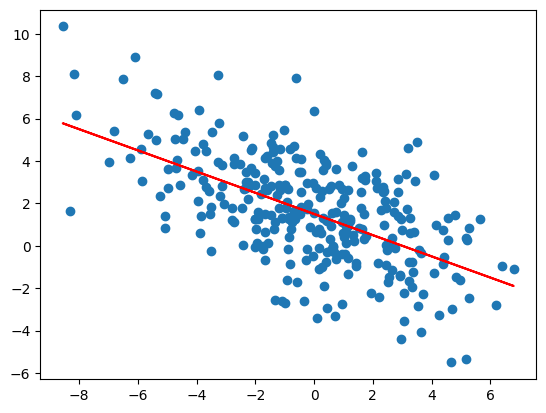

In [17]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 1], y_noise)
plt.plot(X[:, 1], y, color="red")

In [18]:
def regression_coeffs(data):
    x = data[:, :-1]
    y = data[:, -1]
    coef = np.linalg.lstsq(x, y, rcond=None)[0]

    return coef

In [19]:
dataset = np.hstack([X, y_noise[:, np.newaxis]])
dataset

array([[ 1.00000000e+00, -1.10335995e+00, -2.62318714e+00],
       [ 1.00000000e+00,  5.81923257e-01,  2.82600659e+00],
       [ 1.00000000e+00,  1.73131137e+00,  3.10115388e+00],
       [ 1.00000000e+00,  1.62585666e+00,  4.44290314e+00],
       [ 1.00000000e+00, -9.67167348e-01,  1.79594119e+00],
       [ 1.00000000e+00, -4.57779122e+00,  2.87193054e+00],
       [ 1.00000000e+00, -2.01326903e+00,  2.84936458e+00],
       [ 1.00000000e+00,  4.08963372e-01, -7.48239647e-01],
       [ 1.00000000e+00, -1.97990824e+00,  7.74011535e-01],
       [ 1.00000000e+00,  1.01330738e+00,  2.25201634e+00],
       [ 1.00000000e+00,  2.48376432e+00, -1.79101032e-01],
       [ 1.00000000e+00,  3.38042038e+00, -1.21867597e+00],
       [ 1.00000000e+00, -4.37933679e-01,  2.52664513e+00],
       [ 1.00000000e+00,  3.22209187e+00, -7.81165093e-01],
       [ 1.00000000e+00,  1.53429385e-02,  6.33434245e+00],
       [ 1.00000000e+00, -3.69069659e+00,  2.78376441e+00],
       [ 1.00000000e+00, -6.51613166e+00

In [20]:
res = regression_coeffs(dataset)
res

array([ 1.57545378, -0.50689414])

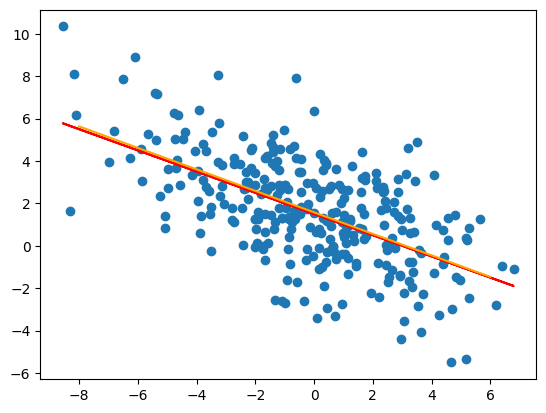

In [21]:
plt.scatter(X[:, 1], y_noise)

test = np.array([[1, -8], [1, 6]])
plt.plot(X[:, 1], y, color="red")
plt.plot(test[:, 1], test @ res, color="orange")

In [26]:
db = DoubleBootstrap(dataset, regression_coeffs)


ci = db.confidence_interval(confidence_level, seed=42, side="two", n_jobs=-1)


In [27]:
print(ci)

lower = [ 1.32731596 -0.59917996]
upper = [ 1.80754835 -0.42036916]
confidence level = 0.95, side = two


In [30]:
a = np.array([[], []])
a

DoubleBootstrap(a, lambda x: x**2)

In [13]:
# Mean over the axis 0
rng = np.random.default_rng(123)

dataset = rng.normal(4, 3, size=(1000, 5, 5))


def mean_mat(x):
    return np.mean(x, axis=0)


print(mean_mat(dataset))


[[3.97415827 4.05517178 3.98702731 3.8743683  4.053281  ]
 [3.85367802 4.04472862 3.90890697 3.97792991 4.09252102]
 [4.12935094 4.01554232 4.01457519 3.94975741 4.0721076 ]
 [4.142231   4.13575172 4.03679546 3.93236058 4.007144  ]
 [4.14654217 4.07239243 3.87138847 4.03090362 3.89220331]]


In [14]:
db = DoubleBootstrap(dataset, mean_mat)
ci = db.confidence_interval(0.95, n_jobs=-1)
print(ci)

lower = [[3.77313248 3.8721037  3.79547257 3.69624916 3.86000403]
 [3.67563182 3.84544858 3.744326   3.79392845 3.91720077]
 [3.9548665  3.85227244 3.808004   3.77592383 3.89917728]
 [3.95913657 3.95305848 3.84893644 3.74300189 3.82758327]
 [3.94760364 3.89692713 3.6772036  3.85419191 3.70934928]]
upper = [[4.17245657 4.24018566 4.18294284 4.05081752 4.24807656]
 [4.03594012 4.23683128 4.07232599 4.16406501 4.26635223]
 [4.32902041 4.17415335 4.21926477 4.1296225  4.2521315 ]
 [4.32601862 4.32236645 4.22603588 4.12548917 4.18934303]
 [4.34365656 4.2438102  4.05307537 4.21620598 4.07078894]]
confidence level = 0.95, side = two
